# Homework 09: Feature Engineering

This notebook turns the Stage 08 ETF-style EDA findings into reusable features. It stays inside `homework09/`; the ongoing `project/` is not changed.

In [1]:
# Packages used: pandas and matplotlib

## 1. Load the ETF Dataset

The notebook loads the committed ETF input from `data/raw/etf_prices.csv`. Keeping the raw file separate from the feature code makes the analysis reproducible and lets the same feature pipeline work on updated data.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RAW = Path('data/raw')
raw_path = RAW / 'etf_prices.csv'
df = pd.read_csv(raw_path, parse_dates=['date'])

required_columns = {'date', 'ticker', 'close', 'volume', 'daily_return', 'abs_return'}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f'Missing required columns: {sorted(missing_columns)}')

df = df.sort_values(['ticker', 'date']).reset_index(drop=True)
df.head()

,date,ticker,close,volume,daily_return,abs_return
0,2024-01-02,GLD,190.651343,1.263619e+07,0.003428,0.003428
1,2024-01-03,GLD,189.517833,1.194967e+07,-0.005945,0.005945
2,2024-01-04,GLD,188.444572,1.333109e+07,-0.005663,0.005663
3,2024-01-05,GLD,189.109948,1.029073e+07,0.003531,0.003531
4,2024-01-08,GLD,190.160468,1.120698e+07,0.005555,0.005555


## 2. Feature 1: Five-Day Momentum

Stage 08 showed different medium-term price paths. Five-day percentage change converts price levels into a comparable directional signal within each ETF.

In [3]:
from src.features import add_momentum, add_rolling_volatility, add_ticker_one_hot

featured = add_momentum(df, periods=5)
featured[['date', 'ticker', 'close', 'momentum_5d']].head(8)

,date,ticker,close,momentum_5d
0,2024-01-02,GLD,190.651343,NaN
1,2024-01-03,GLD,189.517833,NaN
2,2024-01-04,GLD,188.444572,NaN
3,2024-01-05,GLD,189.109948,NaN
4,2024-01-08,GLD,190.160468,NaN
5,2024-01-09,GLD,188.951648,-0.008915
6,2024-01-10,GLD,186.368552,-0.016617
7,2024-01-11,GLD,187.734286,-0.003769


## 3. Feature 2: Ten-Day Rolling Volatility

Stage 08 identified a shock and changing return dispersion. Rolling volatility measures recent risk using only each ticker's own past returns.

In [4]:
featured = add_rolling_volatility(featured, window=10)
featured[['date', 'ticker', 'daily_return', 'volatility_10d']].head(12)

,date,ticker,daily_return,volatility_10d
0,2024-01-02,GLD,0.003428,NaN
1,2024-01-03,GLD,-0.005945,NaN
2,2024-01-04,GLD,-0.005663,NaN
3,2024-01-05,GLD,0.003531,NaN
4,2024-01-08,GLD,0.005555,NaN
5,2024-01-09,GLD,-0.006357,NaN
6,2024-01-10,GLD,-0.013671,NaN
7,2024-01-11,GLD,0.007328,NaN
8,2024-01-12,GLD,-0.005814,NaN
9,2024-01-15,GLD,-0.014615,0.007796


## 4. Feature 3: One-Hot Ticker Encoding

ETF identity is nominal: SPY is not greater or smaller than TLT. One-hot encoding adds separate indicators without imposing a false numeric order. Frequency encoding would be uninformative here because the panel is balanced.

In [5]:
featured = add_ticker_one_hot(featured)
ticker_columns = [column for column in featured.columns if column.startswith('ticker_')]
featured[['ticker', *ticker_columns]].head()

,ticker,ticker_GLD,ticker_SPY,ticker_TLT,ticker_VNQ
0,GLD,1,0,0,0
1,GLD,1,0,0,0
2,GLD,1,0,0,0
3,GLD,1,0,0,0
4,GLD,1,0,0,0


## 5. Future Target and Feature Checks

The target is the next business day's return, created with a within-ticker shift. This avoids evaluating a feature against the same return used to construct it.

In [6]:
featured['next_day_return'] = featured.groupby('ticker')['daily_return'].shift(-1)
analysis = featured.dropna(subset=['momentum_5d', 'volatility_10d', 'next_day_return']).copy()

correlation_check = analysis[['momentum_5d', 'volatility_10d', 'next_day_return']].corr()
correlation_check

,momentum_5d,volatility_10d,next_day_return
momentum_5d,1.000000,-0.033012,-0.028347
volatility_10d,-0.033012,1.000000,0.029744
next_day_return,-0.028347,0.029744,1.000000


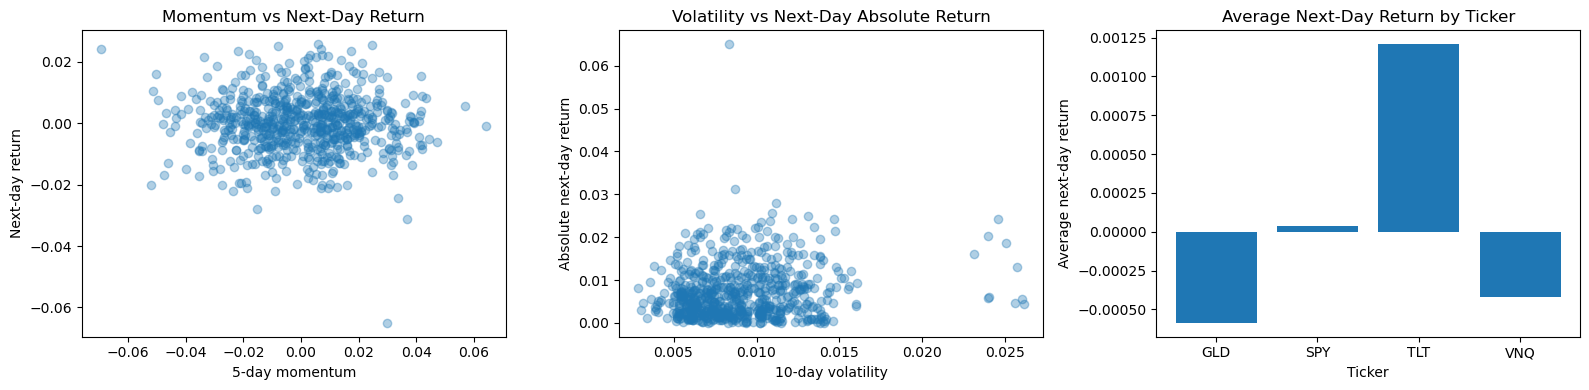

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].scatter(analysis['momentum_5d'], analysis['next_day_return'], alpha=0.35)
axes[0].set(title='Momentum vs Next-Day Return', xlabel='5-day momentum', ylabel='Next-day return')

axes[1].scatter(analysis['volatility_10d'], analysis['next_day_return'].abs(), alpha=0.35)
axes[1].set(title='Volatility vs Next-Day Absolute Return', xlabel='10-day volatility', ylabel='Absolute next-day return')

ticker_target = analysis.groupby('ticker')['next_day_return'].mean()
axes[2].bar(ticker_target.index, ticker_target.values)
axes[2].set(title='Average Next-Day Return by Ticker', xlabel='Ticker', ylabel='Average next-day return')
plt.tight_layout()
plt.show()

## 6. Interpretation

- Momentum tests whether recent direction carries into the next day. A weak correlation is still informative: short-horizon momentum may not be useful by itself.
- Rolling volatility tests whether recent risk is associated with the magnitude of future moves. It is a risk-state feature, not necessarily a directional predictor.
- Ticker indicators allow a later model to estimate different baseline behavior by asset class without assuming an ordinal relationship.

These checks are exploratory. A real strategy would use chronological train/test splits, longer histories, transaction costs, and no look-ahead information.

## 7. Save the Feature Table

In [8]:
processed_dir = Path('data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)
feature_path = processed_dir / 'etf_features.csv'
featured.to_csv(feature_path, index=False)
print('Saved:', feature_path, '| Shape:', featured.shape)

Saved: data\processed\etf_features.csv | Shape: (720, 13)
